In [1]:
import os

PROJECT_ROOT = '/home/user/projects/SoftStairs-QAT'
LOG_ROOT     = os.path.join(PROJECT_ROOT, 'experiments', 'CV', 'logs')

os.makedirs(LOG_ROOT, exist_ok=True)
print("LOG_ROOT:", LOG_ROOT)

DATASET = 'TinyImageNet'

import torch
import torch.nn as nn
import torchvision.models as models

LOG_ROOT: /home/user/projects/SoftStairs-QAT/experiments/CV/logs


In [2]:
import timm


def get_model(model_name, n_classes):
    model = timm.create_model(
        model_name,
        pretrained=True,
        num_classes=n_classes,
    )
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return model.to(device)

In [3]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
import pytorch_lightning as pl
import random

MODEL_NAME = 'efficientformer_l1.snap_dist_in1k'  
DATASET_PATH = os.path.expanduser('~/projects/SoftStairs-QAT/data/tiny-imagenet-200')
BATCH_SIZE = 16

_temp_model = timm.create_model(MODEL_NAME, pretrained=False)
data_config = timm.data.resolve_model_data_config(_temp_model)
del _temp_model

INPUT_SIZE = data_config['input_size'][-1]         
_mean = data_config['mean']                          
_std  = data_config['std']                           

print(f"[{MODEL_NAME}] INPUT_SIZE={INPUT_SIZE}, mean={_mean}, std={_std}")


train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(INPUT_SIZE, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=_mean, std=_std),
])

test_transform = transforms.Compose([
    transforms.Resize(INPUT_SIZE),
    transforms.CenterCrop(INPUT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=_mean, std=_std),
])

DATASET_PATH = os.path.expanduser('~/projects/SoftStairs-QAT/data/tiny-imagenet-200')
BATCH_SIZE = 16

IMG_EXT = ('.jpg', '.jpeg', '.png', '.ppm', '.bmp', '.pgm', '.tif', '.tiff', '.webp')
def is_valid_file(path):
    return path.lower().endswith(IMG_EXT)

train_dataset = ImageFolder(
    root=os.path.join(DATASET_PATH, 'train'),
    transform=train_transform,
    is_valid_file=is_valid_file,
)
val_dataset = ImageFolder(
    root=os.path.join(DATASET_PATH, 'val'),
    transform=test_transform,
    is_valid_file=is_valid_file,
)

pl.seed_everything(42)

print("train classes:", len(train_dataset.classes))
print("val classes:  ", len(val_dataset.classes))
print("train size:   ", len(train_dataset))
print("val size:     ", len(val_dataset))


N_TRAIN_SUBSET = 20000
N_VAL_SUBSET   = 10000

random.seed(42)

def stratified_indices(dataset, total_size):
    targets = [y for _, y in dataset.samples]
    n_classes = len(dataset.classes)
    per_class = total_size // n_classes

    indices = []
    for c in range(n_classes):
        class_idxs = [i for i, y in enumerate(targets) if y == c]
        if len(class_idxs) < per_class:
            raise ValueError(f"Класс {c}: доступно {len(class_idxs)}, нужно {per_class}")
        indices.extend(random.sample(class_idxs, per_class))
    return indices

train_idx = stratified_indices(train_dataset, N_TRAIN_SUBSET)
val_idx   = stratified_indices(val_dataset,   N_VAL_SUBSET)

train_subset = Subset(train_dataset, train_idx)
val_subset   = Subset(val_dataset,   val_idx)

train_loader = DataLoader(
    train_subset, batch_size=BATCH_SIZE, shuffle=True,
    drop_last=True, pin_memory=True, num_workers=4,
)
val_loader = DataLoader(
    val_subset, batch_size=BATCH_SIZE, shuffle=False,
    drop_last=False, num_workers=4,
)

train_labels = [train_dataset[i][1] for i in train_idx]
val_labels   = [val_dataset[i][1]   for i in val_idx]
print()
print("classes in train subset:", len(set(train_labels)))
print("classes in val subset:  ", len(set(val_labels)))

print("train_dataset size:    ", len(train_dataset))       # 100000
print("train_idx size:        ", len(train_idx))           # 10000
print("train_subset size:     ", len(train_subset))        # 10000
print("train_loader batches:  ", len(train_loader))        # 10000 // 32 = 312

print("val_dataset size:      ", len(val_dataset))         # 10000
print("val_idx size:          ", len(val_idx))             # 5000
print("val_subset size:       ", len(val_subset))          # 5000
print("val_loader batches:    ", len(val_loader))          # 5000 / 32 ≈ 157

Seed set to 42


[efficientformer_l1.snap_dist_in1k] INPUT_SIZE=224, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)
train classes: 200
val classes:   200
train size:    100000
val size:      10000

classes in train subset: 200
classes in val subset:   200
train_dataset size:     100000
train_idx size:         20000
train_subset size:      20000
train_loader batches:   1250
val_dataset size:       10000
val_idx size:           10000
val_subset size:        10000
val_loader batches:     625


In [5]:
import torch

def reset_specific_gpu(gpu_id=0):
    if torch.cuda.is_available():
        with torch.cuda.device(gpu_id):
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.synchronize()
            print(f"GPU {gpu_id} reset")
            print(f"Memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

reset_specific_gpu(0)

example_batch = next(iter(train_loader))
print(example_batch[0].shape, example_batch[1].shape)

del example_batch
torch.cuda.empty_cache()

GPU 0 reset
Memory allocated: 0.00 GB
torch.Size([16, 3, 224, 224]) torch.Size([16])


In [4]:
from softstairs_qat import SoftStairsQuantizer, QuantizationConfig
import pytorch_lightning as pl


class SSQStep(pl.Callback):
    def on_train_epoch_start(self, trainer, pl_module):
        epoch = trainer.current_epoch
        if not pl_module.quantizer:
            return
        if epoch > 0:
            pl_module.quantizer.step()
        t_value = pl_module.quantizer.t
        pl_module.log('quantizer_t', t_value, on_epoch=True, on_step=False)
        pl_module.log('quantizer_tback', pl_module.quantizer.current_backward_t,
                      on_step=False)

    def on_validation_epoch_start(self, trainer, pl_module):
        if pl_module.quantizer:
            t_value = pl_module.quantizer.t
            pl_module.log('quantizer_t', t_value, on_epoch=True, on_step=False)
            pl_module.log('quantizer_tback', pl_module.quantizer.current_backward_t,
                          on_step=False)

W1005 17:53:32.112000 7070 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W1005 17:53:32.142000 7070 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


In [6]:
from torch.ao.quantization import QConfig
from torch.ao.quantization.fake_quantize import FakeQuantize
from torch.ao.quantization.observer import HistogramObserver, PlaceholderObserver


def get_weight_only_qconfig(bit_width=8):
    if bit_width == 8:
        weight_fake_quant = FakeQuantize.with_args(
            observer=HistogramObserver,
            quant_min=-128, quant_max=127,
            dtype=torch.qint8, qscheme=torch.per_tensor_affine,
        )
    elif bit_width == 4:
        weight_fake_quant = FakeQuantize.with_args(
            observer=HistogramObserver,
            quant_min=-8, quant_max=7,
            dtype=torch.qint8, qscheme=torch.per_tensor_affine,
        )
    else:
        raise ValueError(f"Unsupported bit width: {bit_width}")

    activation_fake_quant = PlaceholderObserver.with_args(
        dtype=torch.float32, is_dynamic=False,
    )
    return QConfig(activation=activation_fake_quant, weight=weight_fake_quant)


qconfig_weight_only = get_weight_only_qconfig(8)
qconfig_weight_only_int4 = get_weight_only_qconfig(4)

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import pytorch_lightning as pl
from torchmetrics import MetricCollection
from torchmetrics.classification import Accuracy, F1Score, ConfusionMatrix

from softstairs_qat import SoftStairsQuantizer, QuantizationConfig
from softstairs_qat.utils.metrics import ClassificationMargin, LogitNormDiff


class TinyImageNetModule(pl.LightningModule):
    def __init__(self, model_name, model_hparams, optimizer_name, optimizer_hparams,
                 fake_quant=False, torch_qat=False, quantization_hparams={}):
        super().__init__()
        self.save_hyperparameters()

        n_classes = self.hparams.model_hparams['n_classes']
        self.model = get_model(model_name, n_classes)

        self.torch_qat = torch_qat
        self.fake_quant = fake_quant

        self._prepare_quantization()

        self.loss_module = nn.CrossEntropyLoss()

        self.train_metrics = MetricCollection({
            'mtr/acc': Accuracy(task="multiclass", num_classes=n_classes),
            'mtr/f1':  F1Score(task="multiclass", num_classes=n_classes, average='macro'),
        })
        self.val_metrics = MetricCollection({
            'mtr/acc': Accuracy(task="multiclass", num_classes=n_classes),
            'mtr/f1':  F1Score(task="multiclass", num_classes=n_classes, average='macro'),
        })
        self.test_metrics = MetricCollection({
            'mtr/acc': Accuracy(task="multiclass", num_classes=n_classes),
            'mtr/f1':  F1Score(task="multiclass", num_classes=n_classes, average='macro'),
        })

        self.train_margin = ClassificationMargin()
        self.val_margin   = ClassificationMargin()

        self.val_lognorm = LogitNormDiff()

        if self.fake_quant:
            self.val_metrics_quant = MetricCollection({
                'mtr/acc_quant': Accuracy(task="multiclass", num_classes=n_classes),
                'mtr/f1_quant':  F1Score(task="multiclass", num_classes=n_classes,
                                         average='macro'),
            })
            self.val_margin_quant = ClassificationMargin()

        self.val_confusion  = ConfusionMatrix(task="multiclass", num_classes=n_classes)
        self.test_confusion = ConfusionMatrix(task="multiclass", num_classes=n_classes)

        _size = INPUT_SIZE
        self.example_input_array = torch.zeros((1, 3, _size, _size), dtype=torch.float32)

    def _prepare_quantization(self):
        self.quantizer = None
        if self.torch_qat:
            from torch.quantization import prepare_qat
            n_bits = self.hparams.quantization_hparams['n_bits']
            qconfig = get_weight_only_qconfig(n_bits)
            self.model.qconfig = qconfig
            prepare_qat(self.model, inplace=True)
        else:
            excluded_modules = {
                n for n, _ in self.model.named_modules()
                if ("norm" in n.lower() or "patch_embed" in n.lower() or "aux" in n.lower())
            }
            qconfig = QuantizationConfig(**self.hparams.quantization_hparams)
            self.quantizer = SoftStairsQuantizer(
                self.model, qconfig, excluded_modules=excluded_modules,
            )

    def forward(self, imgs):
        # timm-модели возвращают тензор логитов напрямую
        return self.model(imgs)

    def configure_optimizers(self):
        if self.hparams.optimizer_name == "Adam":
            optimizer = optim.AdamW(self.parameters(), **self.hparams.optimizer_hparams)
        elif self.hparams.optimizer_name == "SGD":
            optimizer = optim.SGD(self.parameters(), **self.hparams.optimizer_hparams)
        else:
            assert False, f'Unknown optimizer: "{self.hparams.optimizer_name}"'

        scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[20, 27], gamma=0.1)
        return [optimizer], [scheduler]

    def training_step(self, batch, batch_idx):
        imgs, labels = batch
        logits = self(imgs)
        loss = self.loss_module(logits, labels)

        preds = logits.argmax(-1)
        self.train_metrics.update(preds, labels)
        self.train_margin.update(logits.detach(), labels)

        self.log_dict(self.train_metrics, on_step=True, on_epoch=True, prog_bar=True)
        self.log('loss/train', loss, on_step=True, on_epoch=True, prog_bar=False)
        self.log('mtr/margin', self.train_margin, on_step=False, on_epoch=True, prog_bar=False)
        return loss

    def on_train_epoch_start(self):
        if self.quantizer:
            self.log('epoch_start_quant_error',
                     self.quantizer.estimate_current_quant_error(),
                     on_epoch=True, prog_bar=True)

    def on_train_epoch_end(self):
        if self.quantizer:
            self.log('epoch_end_quant_error',
                     self.quantizer.estimate_current_quant_error(),
                     on_epoch=True, prog_bar=True)

    def validation_step(self, batch, batch_idx):
        imgs, labels = batch

        logits_fp = self(imgs)
        loss = self.loss_module(logits_fp, labels)
        preds_fp = logits_fp.argmax(-1)

        self.val_metrics.update(preds_fp, labels)
        self.val_margin.update(logits_fp.detach(), labels)

        self.log_dict(self.val_metrics, on_step=True, on_epoch=True, prog_bar=True)
        self.log('mtr/val_margin', self.val_margin, on_step=False, on_epoch=True, prog_bar=False)
        self.log('loss/val', loss, on_step=False, on_epoch=True, prog_bar=False)

        if not (self.fake_quant and self.quantizer):
            return loss

        state_dict = {k: v.clone() for k, v in self.model.state_dict().items()}
        self.quantizer.fake_quantize()
        try:
            with torch.no_grad():
                logits_q = self(imgs)
            preds_q = logits_q.argmax(-1)
            loss_q = self.loss_module(logits_q, labels)

            self.val_metrics_quant.update(preds_q, labels)
            self.val_margin_quant.update(logits_q.detach(), labels)
            self.val_lognorm.update(logits_fp.detach(), logits_q.detach())

            self.log_dict(self.val_metrics_quant, on_step=False, on_epoch=True, prog_bar=True)
            self.log('mtr/val_margin_quant', self.val_margin_quant,
                    on_step=False, on_epoch=True, prog_bar=False)
            self.log('mtr/val_lognorm', self.val_lognorm,
                    on_step=False, on_epoch=True, prog_bar=False)
            self.log('loss/val_quant', loss_q,
                    on_step=False, on_epoch=True, prog_bar=False)
        finally:
            self.model.load_state_dict(state_dict)
            del state_dict
            self.quantizer.activate_hooks()

        return loss

    def on_validation_epoch_end(self):
        torch.cuda.empty_cache()
        import gc
        gc.collect()

    def test_step(self, batch, batch_idx):
        imgs, labels = batch
        logits = self(imgs)
        preds = logits.argmax(-1)
        self.test_metrics.update(preds, labels)
        self.log_dict(self.test_metrics, on_step=False, on_epoch=True)

    def on_test_epoch_end(self):
        self.test_metrics.reset()

In [8]:
from pytorch_lightning.callbacks import LearningRateMonitor, Callback
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import TQDMProgressBar


class GradSaver(Callback):
    def __init__(self, parameter_name=None):
        self.parameter_name = parameter_name
        self.save_dir = parameter_name.replace('.', '_') if parameter_name else None
        self.epoch_counter = 0
        self.hook = None
        self.grad = None
        self.log_dir = None
        self.parameter = None

    def on_fit_start(self, trainer, pl_module):
        if self.parameter_name is None:
            last_linear = None
            for name, module in pl_module.model.named_modules():
                if isinstance(module, nn.Linear):
                    last_linear = name
            if last_linear is None:
                raise RuntimeError("Не найден линейный слой для сохранения градиентов")
            self.parameter_name = last_linear + '.weight'
            self.save_dir = self.parameter_name.replace('.', '_')

        part = pl_module.model
        for name in self.parameter_name.split('.'):
            part = getattr(part, name)
        self.parameter = part
        self.parameter.requires_grad_ = True

        def gather_grad(param):
            self.grad = param.grad
        self.hook = self.parameter.register_post_accumulate_grad_hook(gather_grad)

    def on_train_epoch_end(self, trainer, pl_module):
        if not pl_module.quantizer:
            return
        if self.log_dir is None:
            self.log_dir = os.path.join(trainer.log_dir, self.save_dir)
            os.makedirs(self.log_dir, exist_ok=True)
        if self.grad is not None:
            torch.save(self.grad.detach().cpu(),
                       os.path.join(self.log_dir, f'grad_{pl_module.current_epoch}.pth'))
        torch.save(
            pl_module.quantizer.upscaled_parameter(
                self.parameter_name + pl_module.quantizer._orig_suffix
            ).detach().cpu(),
            os.path.join(self.log_dir, f'param_{pl_module.current_epoch}.pth'),
        )
        self.epoch_counter += 1

    def on_fit_end(self, trainer, pl_module):
        if self.hook:
            self.hook.remove()


def train_model(model_name, save_name=None, epochs=100, torch_qat=False,
                quantization_hparams={}, retrain=False, **kwargs):
    if save_name is None:
        save_name = model_name

    logger = CSVLogger(save_dir=LOG_ROOT, name=save_name)

    trainer = pl.Trainer(
        accelerator="auto",
        devices=1,
        max_epochs=epochs,
        enable_checkpointing=False,
        callbacks=[
            SSQStep(),
            LearningRateMonitor("epoch"),
            GradSaver(),          
            TQDMProgressBar(refresh_rate=10),
        ],
        logger=logger,
    )
    trainer.logger._default_hp_metric = None

    pl.seed_everything(42)
    model = TinyImageNetModule(
        model_name=model_name,
        quantization_hparams=quantization_hparams | {'n_steps': epochs + 1},
        torch_qat=torch_qat,
        **kwargs,
    )
    trainer.fit(model, train_loader, val_loader)

    return model

## training

In [9]:
N_BITS = 8
TYPE = 'standard'
N_EPOCHS = 30
ASYNC = 1
STRATEGY = 'cyclic'

SAVE_NAME = f"{MODEL_NAME}_{DATASET}_str{STRATEGY}_af{ASYNC}_b{N_BITS}_t{TYPE}_SUBSAMPLE"
# SAVE_NAME = f"{MODEL_NAME}_{DATASET}_b{N_BITS}_t{TYPE}_SUBSAMPLE"
OPT_HPARAMS = {"lr": 5e-5, "weight_decay": 0.05}

model = train_model(
    model_name=MODEL_NAME,
    save_name=SAVE_NAME,
    model_hparams={"n_classes": 200},
    optimizer_name="Adam",
    optimizer_hparams=OPT_HPARAMS,
    quantization_hparams=dict(
        t_scheduler_strategy=STRATEGY,
        async_t_factor=ASYNC,
        t_start=0.9,
        t_end=0.0005,
        n_bits=N_BITS,
        type=TYPE,
        normalized=True,
        symmetric=False,
        half_shift=False,
    ),
    torch_qat='torch' in TYPE,
    retrain=True,
    fake_quant=True,
    epochs=N_EPOCHS,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 42
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃    ┃ Name              ┃ Type                      ┃ Params ┃ Mode  ┃ FLOPs ┃         In sizes ┃ Out sizes ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0  │ model             │ EfficientFormer           │ 11.6 M │ train │ 2.6 B │ [1, 3, 224, 224] │  [1, 200] │
│ 1  │ loss_module       │ CrossEntropyLoss          │      0 │ train │     0 │                ? │         ? │
│ 2  │ train_metrics     │ MetricCollection          │      0 │ train │     0 │                ? │         ? │
│ 3  │ val_metrics       │ MetricCollection          │      0 │ train │     0 │                ? │         ? │
│ 4  │ test_metrics      │ MetricCollection          │      0 │ train │     0 │                ? │         ? │
│ 5  │ train_margin      │ ClassificationMargin      │      0 │ train │     0 │                ? │         ? │
│ 6  │ val_margin        │ ClassificationMargin      │      0 │ train │     0 │                ? │         ? │
│ 7  │ val_lognorm       │ LogitNormDiff             │      0 │ train │     0 │                ? │         ? │
│ 8  │ val_metrics_quant │ MetricCollection          │      0 │ train │     0 │                ? │         ? │
│ 9  │ val_margin_quant  │ ClassificationMargin      │      0 │ train │     0 │                ? │         ? │
│ 10 │ val_confusion     │ MulticlassConfusionMatrix │      0 │ train │     0 │                ? │         ? │
│ 11 │ test_confusion    │ MulticlassConfusionMatrix │      0 │ train │     0 │                ? │         ? │
└────┴───────────────────┴───────────────────────────┴────────┴───────┴───────┴──────────────────┴───────────┘

Trainable params: 11.6 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.6 M                                                                                               
Total estimated model params size (MB): 46.286                                                                     
Modules in train mode: 264                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 2.6 B

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/user/projects/SoftStairs-QAT/.venv/lib/python3.10/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np


def read_results(name, scale='step', version=None, agg_func='last'):
    path = Path(LOG_ROOT) / name
    if not path.exists():
        available = sorted(os.listdir(LOG_ROOT)) if os.path.isdir(LOG_ROOT) else []
        raise FileNotFoundError(
            f"Нет папки: {path}\n"
            f"LOG_ROOT = {LOG_ROOT}\n"
            f"Доступные: {available}"
        )
    if not version:
        version = sorted(os.listdir(path), key=lambda x: float(x.split('_')[-1]))[-1]
    elif isinstance(version, int):
        version = f'version_{version}'
    file = path / version / 'metrics.csv'
    df = pd.read_csv(file)

    keep = []
    for c in df.columns:
        if c.endswith('_epoch'):
            keep.append(c)
        elif c in ('epoch', 'step',
                   'lr-AdamW',
                   'quantizer_t', 'quantizer_tback',
                   'loss/val', 'loss/val_quant',
                   'mtr/margin', 'mtr/lognorm',
                   'mtr/val_margin', 'mtr/val_lognorm',
                   'mtr/val_margin_quant', 'mtr/val_lognorm_quant',
                   'mtr/acc_quant', 'mtr/f1_quant',                # ← добавлено
                   'mtr/val_acc', 'mtr/val_f1',
                   'epoch_start_quant_error', 'epoch_end_quant_error'):
            keep.append(c)
    df = df[keep]

    def last_valid(s):
        s = s.dropna()
        return s.iloc[-1] if len(s) else np.nan

    df = df.groupby(scale).agg(last_valid).reset_index()
    alternative_scale = 'step' if scale != 'step' else 'epoch'
    df.drop([c for c in df.columns if alternative_scale in c], axis=1, inplace=True)
    return df, 0.0

array([[<Axes: title={'center': 'losses'}, xlabel='epoch', ylabel='loss/train_epoch'>,
        <Axes: title={'center': 'metrics'}, xlabel='epoch', ylabel='mtr/val_lognorm'>],
       [<Axes: title={'center': 't_schedule'}, xlabel='epoch', ylabel='quantizer_t'>,
        <Axes: title={'center': 'lognorm vs. t_schedule'}, xlabel='quantizer_t', ylabel='mtr/val_lognorm'>]],
      dtype=object)

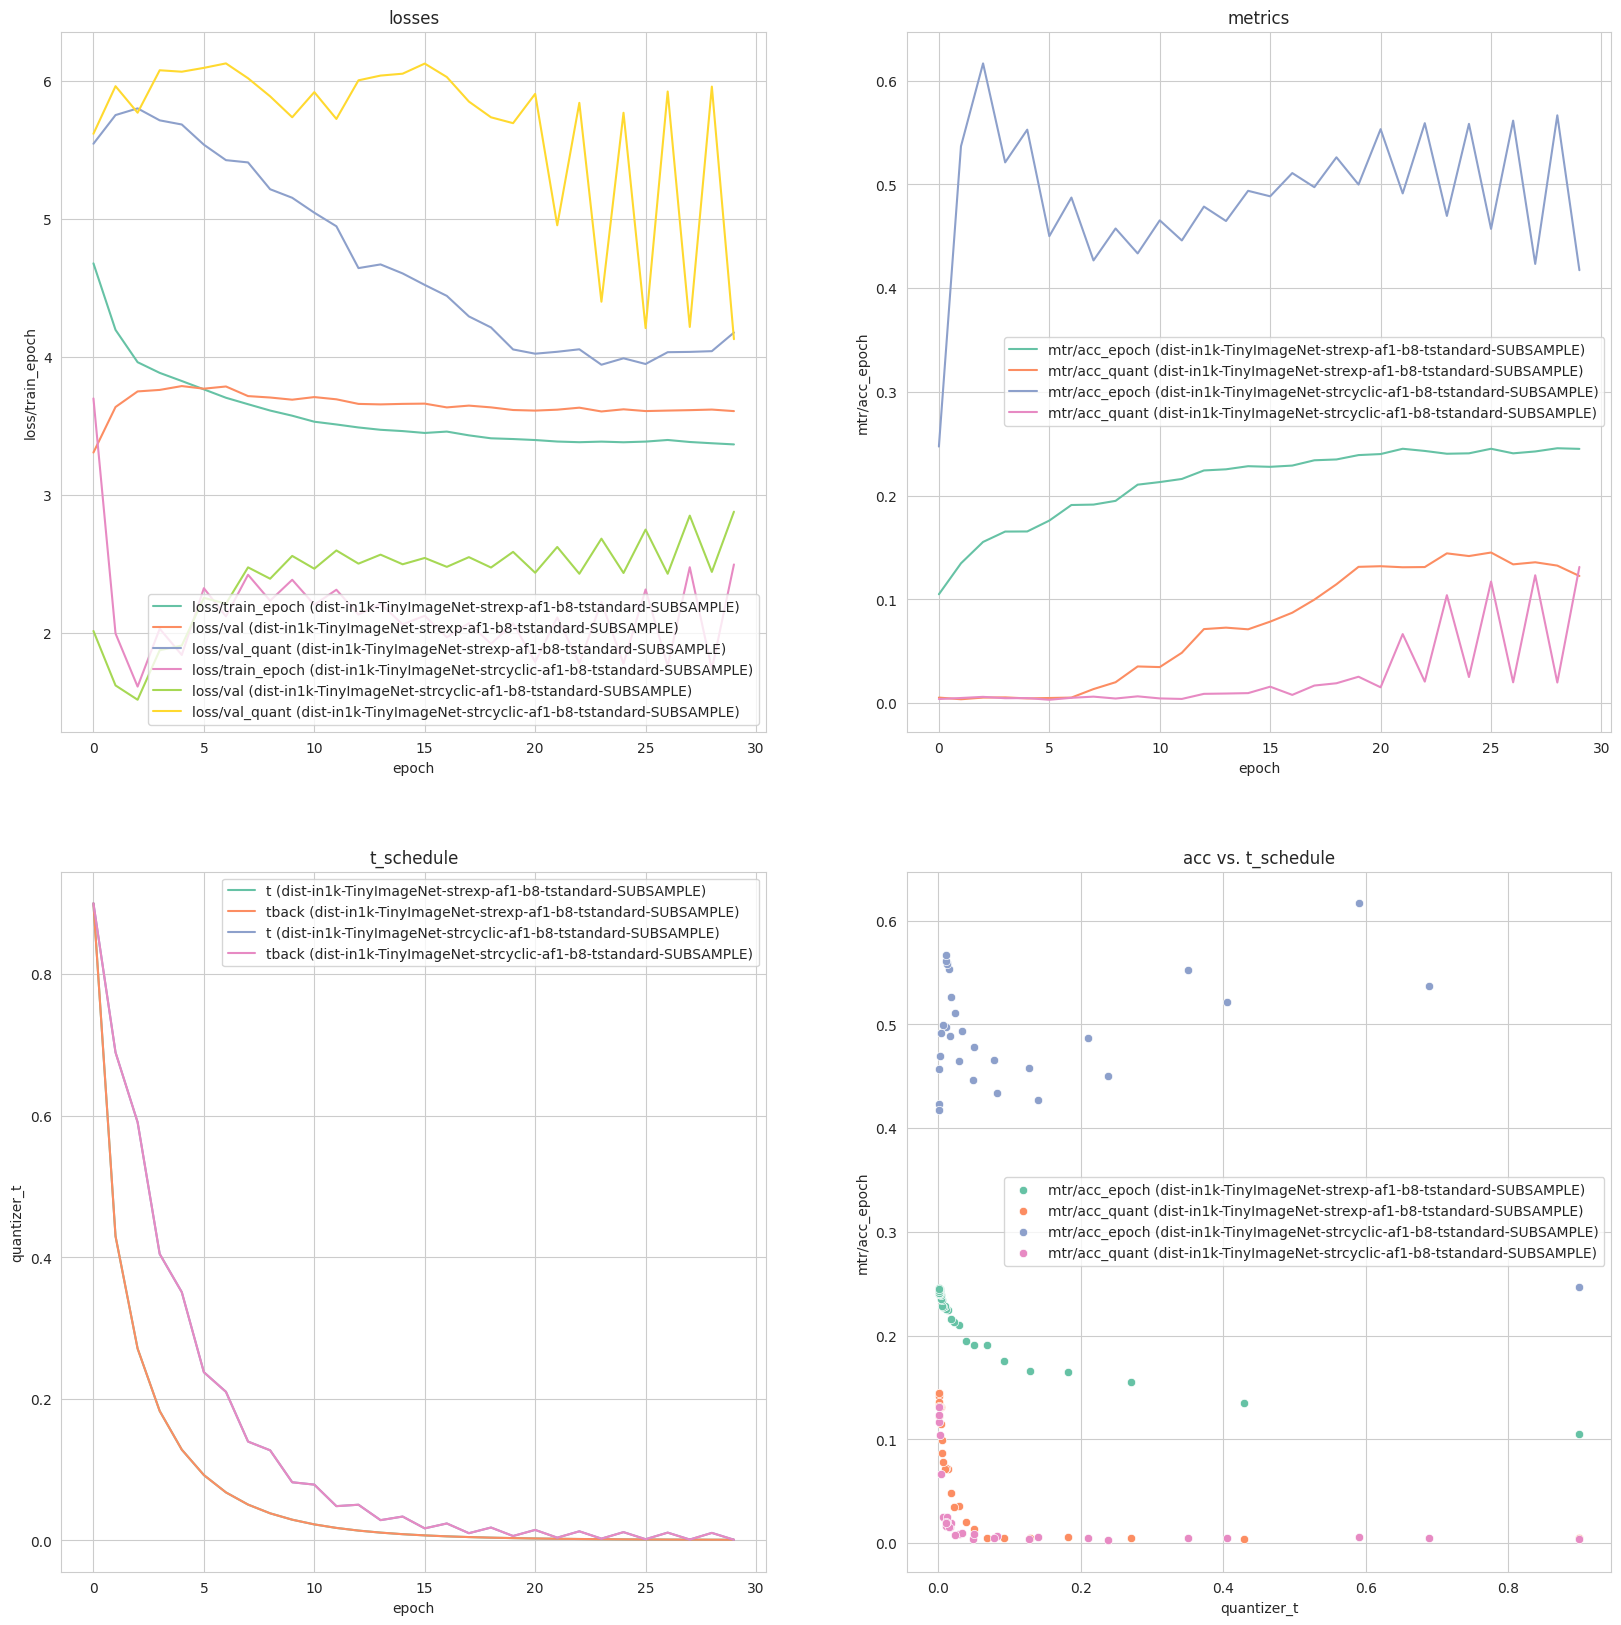

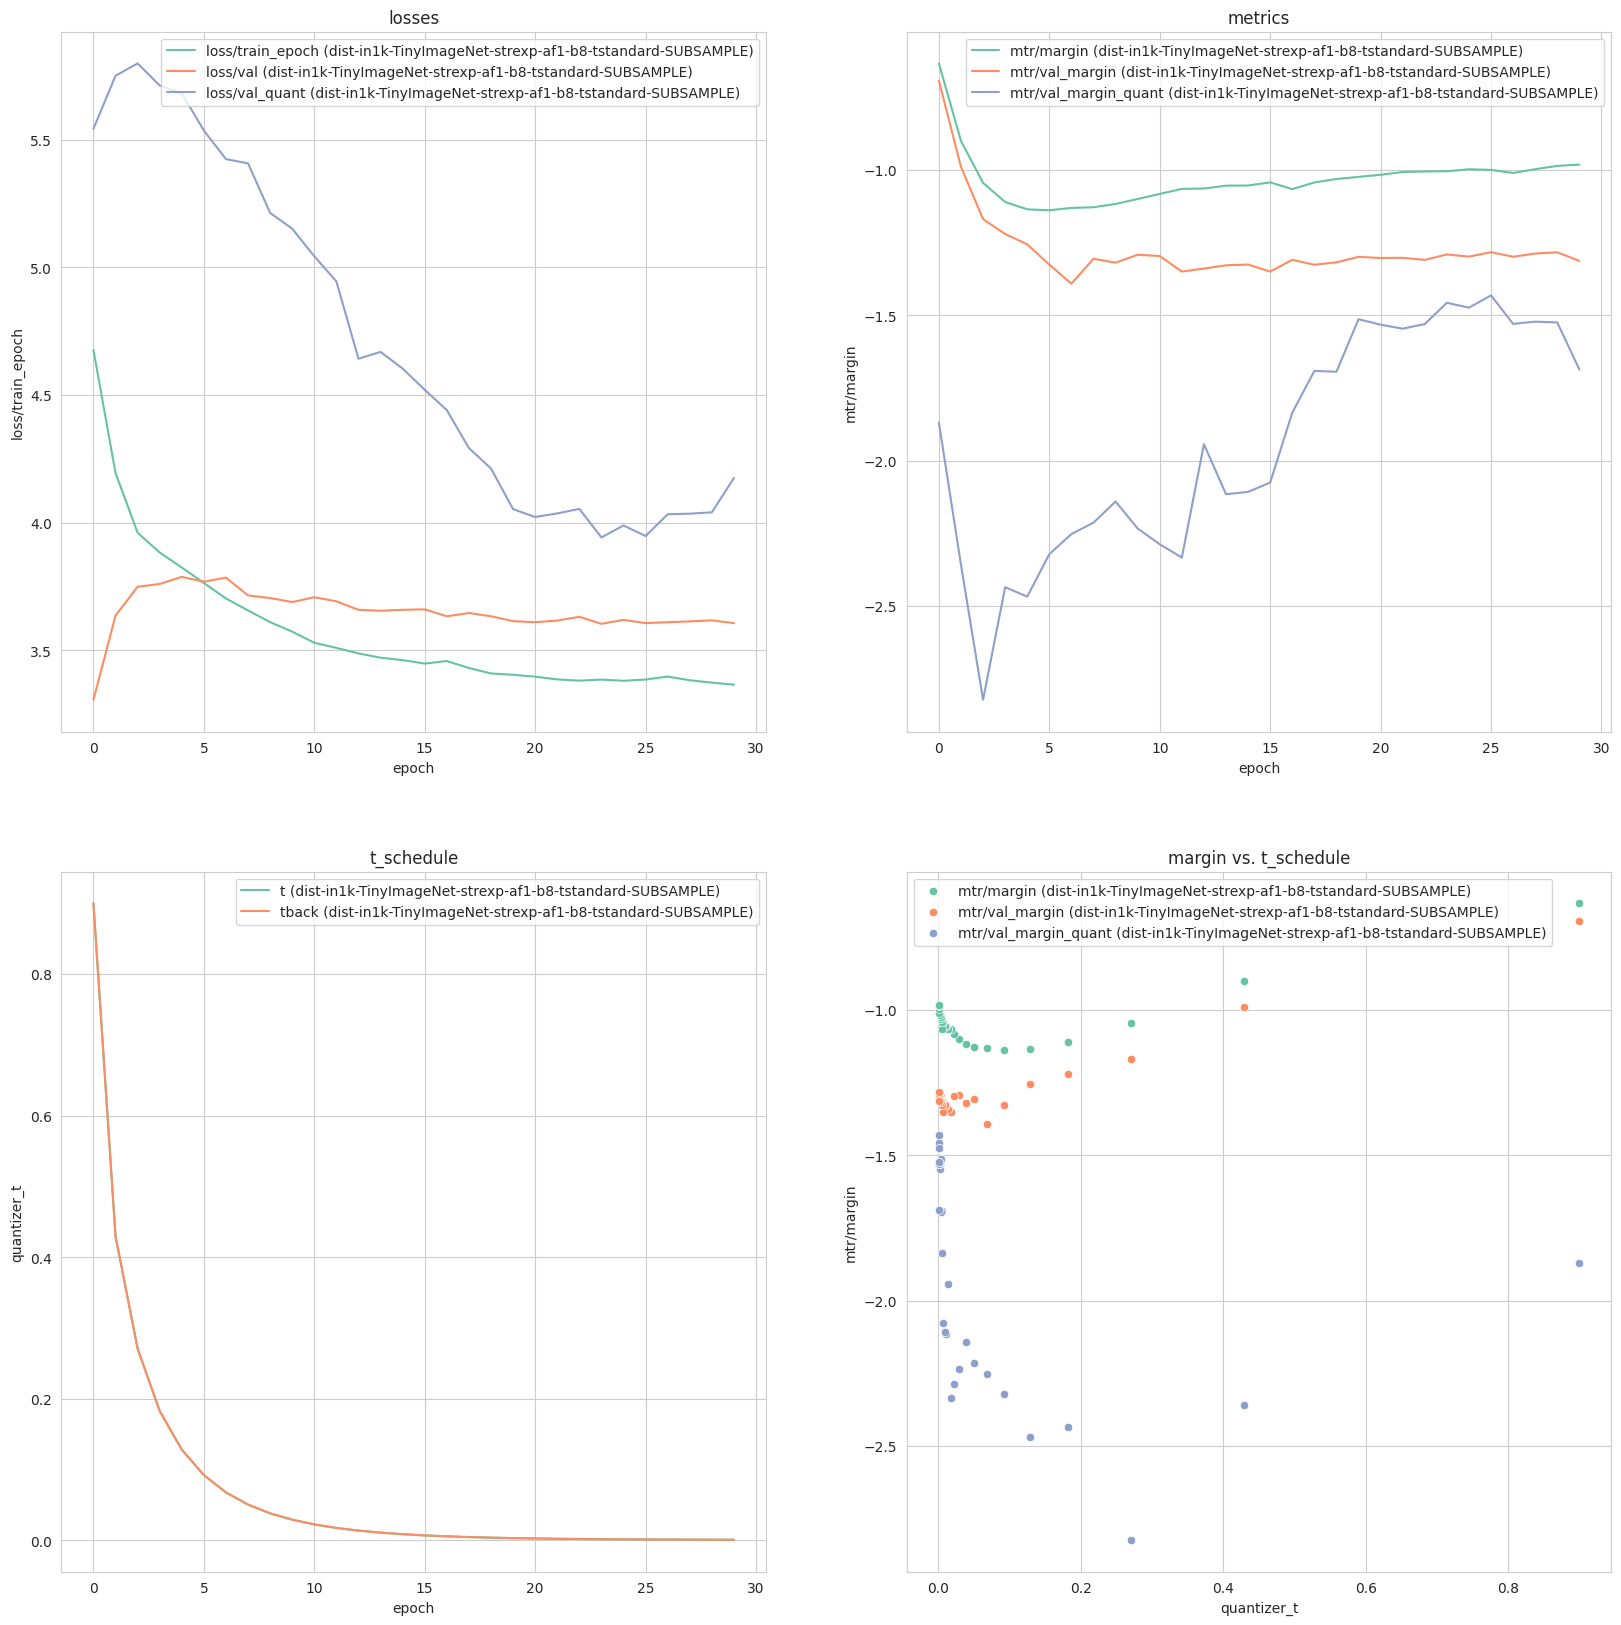

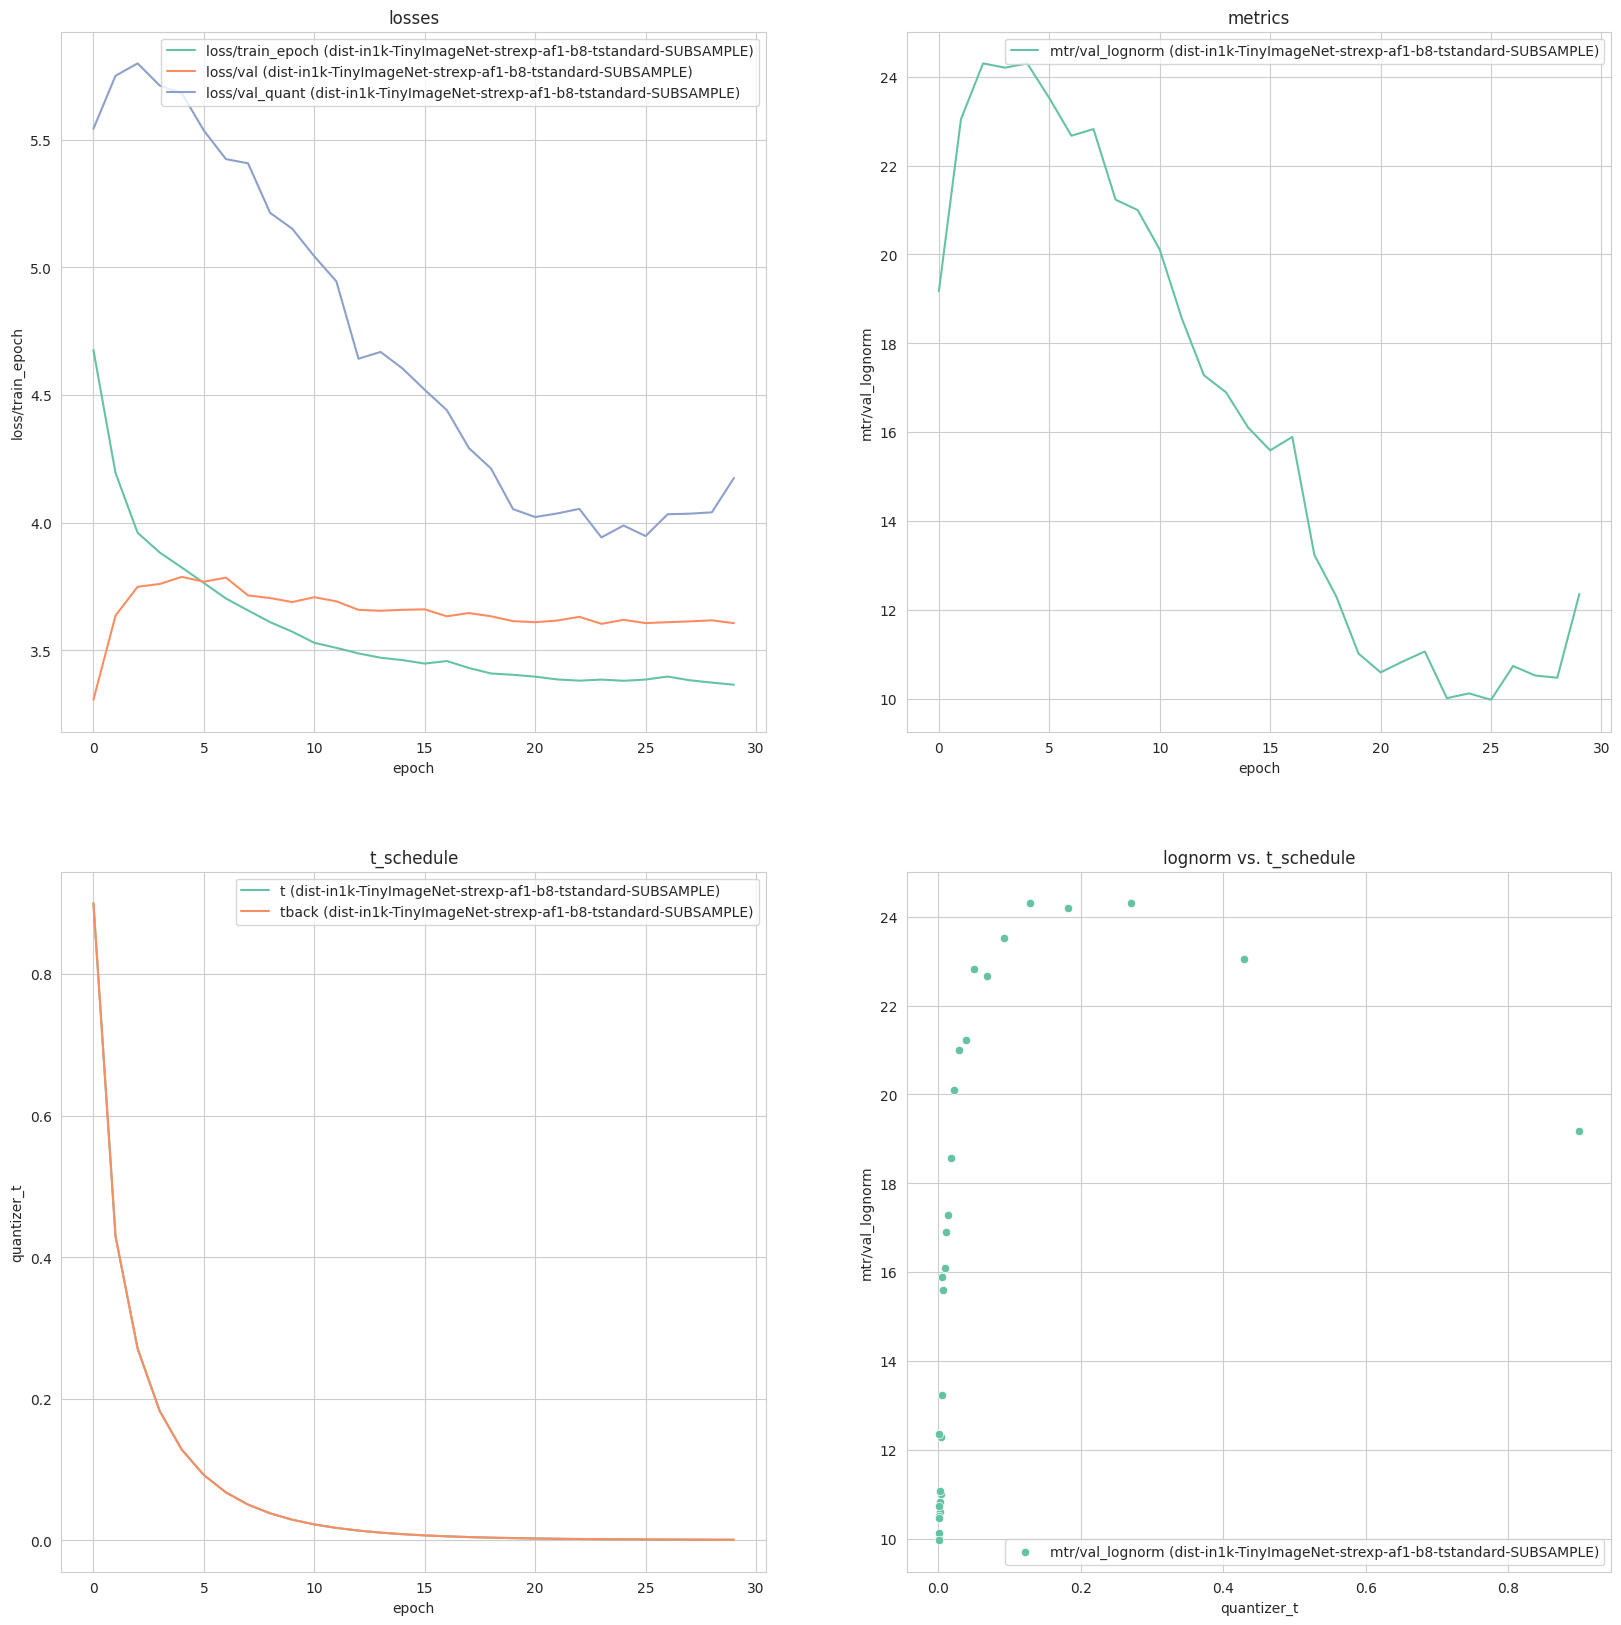

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_palette("Set2")


def plot_dynamics(name, scale='step', metric='acc', axes=None, suffix='',
                  agg_func='mean'):
    name, *version = name.split('#')
    version = int(version[0]) if version else None
    dynamics, final_results = read_results(name, scale, version, agg_func)

    if axes is None:
        fig, axes = plt.subplots(2, 2, figsize=(20, 20))

    for c in [c for c in dynamics.columns if c.startswith('loss/')]:
        sns.lineplot(dynamics, x=scale, y=c, ax=axes[0][0], label=c + suffix)
    axes[0][0].legend()
    axes[0][0].set_title('losses')

    metric_cols = [
        c for c in dynamics.columns
        if (metric is None and c.startswith('mtr/'))
        or (isinstance(metric, str) and metric in c)
    ]
    for c in metric_cols:
        sns.lineplot(dynamics, x=scale, y=c, ax=axes[0][1], label=c + suffix)
    axes[0][1].legend()
    axes[0][1].set_title('metrics')

    if 'quantizer_t' in dynamics.columns:
        ax = axes[1][0]
        sns.lineplot(dynamics, x=scale, y='quantizer_t', ax=ax, label='t' + suffix)
        if 'quantizer_tback' in dynamics.columns:
            sns.lineplot(dynamics, x=scale, y='quantizer_tback', ax=ax,
                         label='tback' + suffix)
        ax.set_title('t_schedule')

        ax = axes[1][1]
        for c in metric_cols:
            sns.scatterplot(dynamics, x='quantizer_t', y=c, ax=ax,
                            label=c + suffix)
        ax.set_title(f'{metric} vs. t_schedule')
    else:
        axes[1][0].set_visible(False)
        axes[1][1].set_visible(False)

    return axes


def plot_comparison(*exps, scale, metric, suffixes=None, agg_func='mean'):
    if suffixes is None:
        suffixes = [f" ({'-'.join(exp.split('_')[2:])})" for exp in exps]
    axes = plot_dynamics(exps[0], scale, metric, agg_func=agg_func, suffix=suffixes[0])
    for exp, suffix in zip(exps[1:], suffixes[1:]):
        axes = plot_dynamics(exp, scale, metric, axes, suffix, agg_func=agg_func)
    return axes


plot_comparison(
    #  'InceptionNet_TinyImageNet_strcyclic_af1_b4_tstandard',
    # 'InceptionNet_TinyImageNet_strcyclic_af1_b4_ttorch_SUBSAMPLE',
    # 'InceptionNet_TinyImageNet_strcyclic_af1_b4_tstandard_SUBSAMPLE',
    # 'InceptionNet_TinyImageNet_strexp_af1_b4_tstandard_SUBSAMPLE',
    # 'SwinTiny_TinyImageNet_strcyclic_af1_b8_tstandard_SUBSAMPLE',
    # 'SwinTiny_TinyImageNet_strexp_af1_b8_tstandard_SUBSAMPLE',
    'efficientformer_l1.snap_dist_in1k_TinyImageNet_strexp_af1_b8_tstandard_SUBSAMPLE',
    'efficientformer_l1.snap_dist_in1k_TinyImageNet_strcyclic_af1_b8_tstandard_SUBSAMPLE',
    scale='epoch', metric='acc', agg_func='mean',
)

plot_comparison(
    # 'InceptionNet_TinyImageNet_strcyclic_af1_b4_tstandard',
    # 'InceptionNet_TinyImageNet_strcyclic_af1_b4_ttorch_SUBSAMPLE',
    # 'InceptionNet_TinyImageNet_strcyclic_af1_b4_tstandard_SUBSAMPLE',
    # 'InceptionNet_TinyImageNet_strexp_af1_b4_tstandard_SUBSAMPLE',
    # 'SwinTiny_TinyImageNet_strcyclic_af1_b8_tstandard_SUBSAMPLE',
    # 'SwinTiny_TinyImageNet_strexp_af1_b8_tstandard_SUBSAMPLE',
    'efficientformer_l1.snap_dist_in1k_TinyImageNet_strexp_af1_b8_tstandard_SUBSAMPLE',
    scale='epoch', metric='margin', agg_func='mean',
)

plot_comparison(
    # 'InceptionNet_TinyImageNet_strcyclic_af1_b4_ttorch_SUBSAMPLE',
    # 'InceptionNet_TinyImageNet_strcyclic_af1_b4_tstandard_SUBSAMPLE',
    # 'InceptionNet_TinyImageNet_strexp_af1_b4_tstandard_SUBSAMPLE',
    # 'SwinTiny_TinyImageNet_strcyclic_af1_b8_tstandard_SUBSAMPLE',
    # 'SwinTiny_TinyImageNet_strexp_af1_b8_tstandard_SUBSAMPLE',
    'efficientformer_l1.snap_dist_in1k_TinyImageNet_strexp_af1_b8_tstandard_SUBSAMPLE',
    scale='epoch', metric='lognorm', agg_func='mean',
)